# 🚀 LOAD SAVED MODEL FOR EVALUATION

**Important:** Run this cell to load your previously saved optimized model before running the evaluation cell.

This will load the model that was saved after hyperparameter tuning so you can evaluate its performance.

In [ ]:
# 🚀 LOAD YOUR SAVED OPTIMIZED MODEL
print("🚀 LOADING SAVED OPTIMIZED MODEL FOR EVALUATION")
print("="*50)

# First, let's see what models are available
models = list_saved_models()

if models:
    print("\n📋 Available saved models:")
    for i, model in enumerate(models, 1):
        save_date = datetime.fromisoformat(model['save_time']).strftime("%Y-%m-%d %H:%M")
        print(f"{i}. {model['name']}")
        print(f"   Saved: {save_date}")
        print(f"   Best score: {model['best_score']:.4f}")
        print()
    
    # Load the best model automatically
    print("🎯 Loading the best model automatically...")
    quick_load_best_model()
    
else:
    print("\n❌ No saved models found!")
    print("💡 Please run the hyperparameter tuning cells first to create a saved model.")
    print("   Then save it using the model saving cell before running this evaluation.")

# Spotify Playlist Data - Exploratory Data Analysis

**Author:** Mike Stanton  
**Date:** November 15, 2025  
**Purpose:** Initial exploration of the Spotify playlist dataset to understand user listening habits and playlist patterns for building a music recommender system.

## Dataset Overview
This analysis focuses on the Spotify playlist dataset containing:
- User IDs (hashed usernames)
- Artist names
- Track names  
- Playlist names

The goal is to identify patterns in listening habits that can inform a collaborative filtering recommender system.

## 1. Import Required Libraries

In [2]:
# Install required packages if not available
import sys
!{sys.executable} -m pip install kagglehub pandas numpy matplotlib seaborn plotly

print("Packages installed successfully!")

Packages installed successfully!


In [3]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Data loading utilities
import zipfile
import os
import kagglehub

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Recommendation system libraries
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error

# Install implicit if not available
import subprocess
import sys

print("Checking for implicit library...")
try:
    import implicit
    print("✅ implicit library is already available!")
except ImportError:
    print("❌ implicit library not found. Installing...")
    try:
        # Try installing with pip
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'implicit'])
        print("✅ implicit library installed via pip!")
        
        # Try importing again
        import implicit
        print("✅ implicit library imported successfully!")
        
    except Exception as e:
        print(f"❌ Installation failed: {e}")
        print("💡 Please try manually installing with: pip install implicit")
        print("💡 Or try: conda install -c conda-forge implicit")
        raise ImportError("Could not install implicit library")

Checking for implicit library...
✅ implicit library is already available!


## 2. Data Loading

Load the Spotify playlist dataset with robust error handling for different file formats and encodings.

In [5]:
# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download("andrewmvd/spotify-playlists")
print(f"Dataset downloaded to: {dataset_path}")

# Find the CSV file (it might be in a ZIP)
csv_files = []
zip_files = []

for file in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, file)
    if file.lower().endswith('.csv'):
        csv_files.append(file_path)
    elif file.lower().endswith('.zip'):
        zip_files.append(file_path)

print(f"Found {len(csv_files)} CSV files and {len(zip_files)} ZIP files")

Dataset downloaded to: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1
Found 1 CSV files and 0 ZIP files


In [6]:
# Load the data with robust error handling
df = None

if csv_files:
    # Direct CSV file found
    csv_file = csv_files[0]
    print(f"Loading CSV file: {csv_file}")
    try:
        df = pd.read_csv(
            csv_file,
            encoding='iso-8859-1',  # Permissive encoding
            sep=',',
            quotechar='"',
            escapechar='\\',
            engine='python',
            on_bad_lines='skip'
        )
    except Exception as e:
        print(f"Error loading CSV directly: {e}")

elif zip_files:
    # Extract and load from ZIP file
    zip_file = zip_files[0]
    print(f"Extracting from ZIP file: {zip_file}")
    try:
        with zipfile.ZipFile(zip_file, 'r') as z:
            csv_name = next((n for n in z.namelist() if n.lower().endswith('.csv')), None)
            if csv_name:
                print(f"Found CSV in ZIP: {csv_name}")
                with z.open(csv_name) as f:
                    df = pd.read_csv(
                        f,
                        encoding='iso-8859-1',
                        sep=',',
                        quotechar='"',
                        escapechar='\\',
                        engine='python',
                        on_bad_lines='skip'
                    )
            else:
                print("No CSV file found in ZIP archive")
    except Exception as e:
        print(f"Error extracting from ZIP: {e}")

if df is not None:
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
else:
    print("Failed to load dataset")

Loading CSV file: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1\spotify_dataset.csv
Dataset loaded successfully!
Shape: (12791243, 4)
Columns: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']
Dataset loaded successfully!
Shape: (12791243, 4)
Columns: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']


In [8]:
# Debug: Check actual column names
if df is not None:
    print("Actual column names in the dataset:")
    for i, col in enumerate(df.columns):
        print(f"{i}: '{col}'")
    print(f"\nDataset shape: {df.shape}")
else:
    print("Dataset is None - loading failed")

Actual column names in the dataset:
0: 'user_id'
1: ' "artistname"'
2: ' "trackname"'
3: ' "playlistname"'

Dataset shape: (12791243, 4)


In [9]:
# Clean column names - remove extra spaces and quotes
if df is not None:
    print("Cleaning column names...")
    print("Before:", list(df.columns))
    
    # Strip spaces and quotes from column names
    df.columns = [col.strip().strip('"') for col in df.columns]
    
    print("After:", list(df.columns))
    print("Column names cleaned successfully!")

Cleaning column names...
Before: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']
After: ['user_id', 'artistname', 'trackname', 'playlistname']
Column names cleaned successfully!


## 3. Initial Data Exploration

In [10]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,user_id,artistname,trackname,playlistname
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010


In [11]:
# Basic dataset information
print("Dataset Info:")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
Number of rows: 12,791,243
Number of columns: 4
Memory usage: 3390.16 MB

Column data types:
user_id         object
artistname      object
trackname       object
playlistname    object
dtype: object

Missing values:
user_id             0
artistname      33536
trackname          88
playlistname       41
dtype: int64
Memory usage: 3390.16 MB

Column data types:
user_id         object
artistname      object
trackname       object
playlistname    object
dtype: object

Missing values:
user_id             0
artistname      33536
trackname          88
playlistname       41
dtype: int64


## 4. Summary Statistics

Calculate key metrics about users, artists, tracks, and playlists.

In [12]:
# Key statistics
stats = {
    'Total Records': df.shape[0],
    'Unique Users': df['user_id'].nunique() if 'user_id' in df.columns else 'N/A',
    'Unique Artists': df['artistname'].nunique() if 'artistname' in df.columns else 'N/A',
    'Unique Tracks': df['trackname'].nunique() if 'trackname' in df.columns else 'N/A',
    'Unique Playlists': df['playlistname'].nunique() if 'playlistname' in df.columns else 'N/A'
}

for key, value in stats.items():
    print(f"{key}: {value:,}" if isinstance(value, int) else f"{key}: {value}")

Total Records: 12,791,243
Unique Users: 15,910
Unique Artists: 287,438
Unique Tracks: 1,999,879
Unique Playlists: 156,884


## 5. Data Visualization

Create visualizations to understand the data distribution and patterns.

In [13]:
# Install networkx for graph visualization
import sys
!{sys.executable} -m pip install networkx

print("NetworkX installed successfully!")

NetworkX installed successfully!


In [14]:
# Import network analysis library
import networkx as nx
from collections import defaultdict
import random

print("Ready to create network graphs!")

Ready to create network graphs!


In [15]:
# Sample the data for network analysis
print("Sampling data for network visualization...")

# Get 100 random users instead of most active users
N_USERS = 200  # Adjust this number based on performance
all_users = df['user_id'].unique()
np.random.seed(42)  # For reproducible results
random_users = np.random.choice(all_users, size=min(N_USERS, len(all_users)), replace=False).tolist()

# Get activity stats for comparison
user_track_counts = df['user_id'].value_counts()
selected_user_counts = user_track_counts[random_users]

print(f"Selected {len(random_users)} random users")
print(f"Random users track counts - Min: {selected_user_counts.min()}, Max: {selected_user_counts.max()}, Avg: {selected_user_counts.mean():.1f}")
print(f"For comparison, most active user has {user_track_counts.iloc[0]} tracks, least active has {user_track_counts.iloc[-1]} tracks")

# Filter data to only include these users
df_sample = df[df['user_id'].isin(random_users)].copy()
print(f"Sample dataset shape: {df_sample.shape}")
print(f"Sample contains {df_sample['user_id'].nunique()} unique users and {df_sample['trackname'].nunique()} unique tracks")

Sampling data for network visualization...
Selected 200 random users
Random users track counts - Min: 1, Max: 12987, Avg: 852.2
For comparison, most active user has 294969 tracks, least active has 1 tracks
Sample dataset shape: (170435, 4)
Sample contains 200 unique users and 108537 unique tracks
Selected 200 random users
Random users track counts - Min: 1, Max: 12987, Avg: 852.2
For comparison, most active user has 294969 tracks, least active has 1 tracks
Sample dataset shape: (170435, 4)
Sample contains 200 unique users and 108537 unique tracks


In [16]:
# Create user-track relationships and find shared tracks
print("Creating user similarity network...")

# Create a dictionary: track -> set of users who have that track
track_to_users = defaultdict(set)
for _, row in df_sample.iterrows():
    track_to_users[row['trackname']].add(row['user_id'])

print(f"Found {len(track_to_users)} unique tracks in sample")

# Create graph where nodes are users and edges represent shared tracks
G = nx.Graph()

# Add all users as nodes
G.add_nodes_from(random_users)

# Add edges between users who share tracks
shared_tracks_count = defaultdict(int)
for track, users in track_to_users.items():
    users_list = list(users)
    # Create edges between every pair of users who share this track
    for i in range(len(users_list)):
        for j in range(i + 1, len(users_list)):
            user1, user2 = users_list[i], users_list[j]
            shared_tracks_count[(user1, user2)] += 1

# Only add edges if users share multiple tracks (to reduce noise)
MIN_SHARED_TRACKS = 2  # Minimum number of shared tracks to create an edge
for (user1, user2), count in shared_tracks_count.items():
    if count >= MIN_SHARED_TRACKS:
        G.add_edge(user1, user2, weight=count, shared_tracks=count)

print(f"Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Edges represent users who share at least {MIN_SHARED_TRACKS} tracks")

Creating user similarity network...
Found 108537 unique tracks in sample
Network created with 200 nodes and 7925 edges
Edges represent users who share at least 2 tracks
Found 108537 unique tracks in sample
Network created with 200 nodes and 7925 edges
Edges represent users who share at least 2 tracks


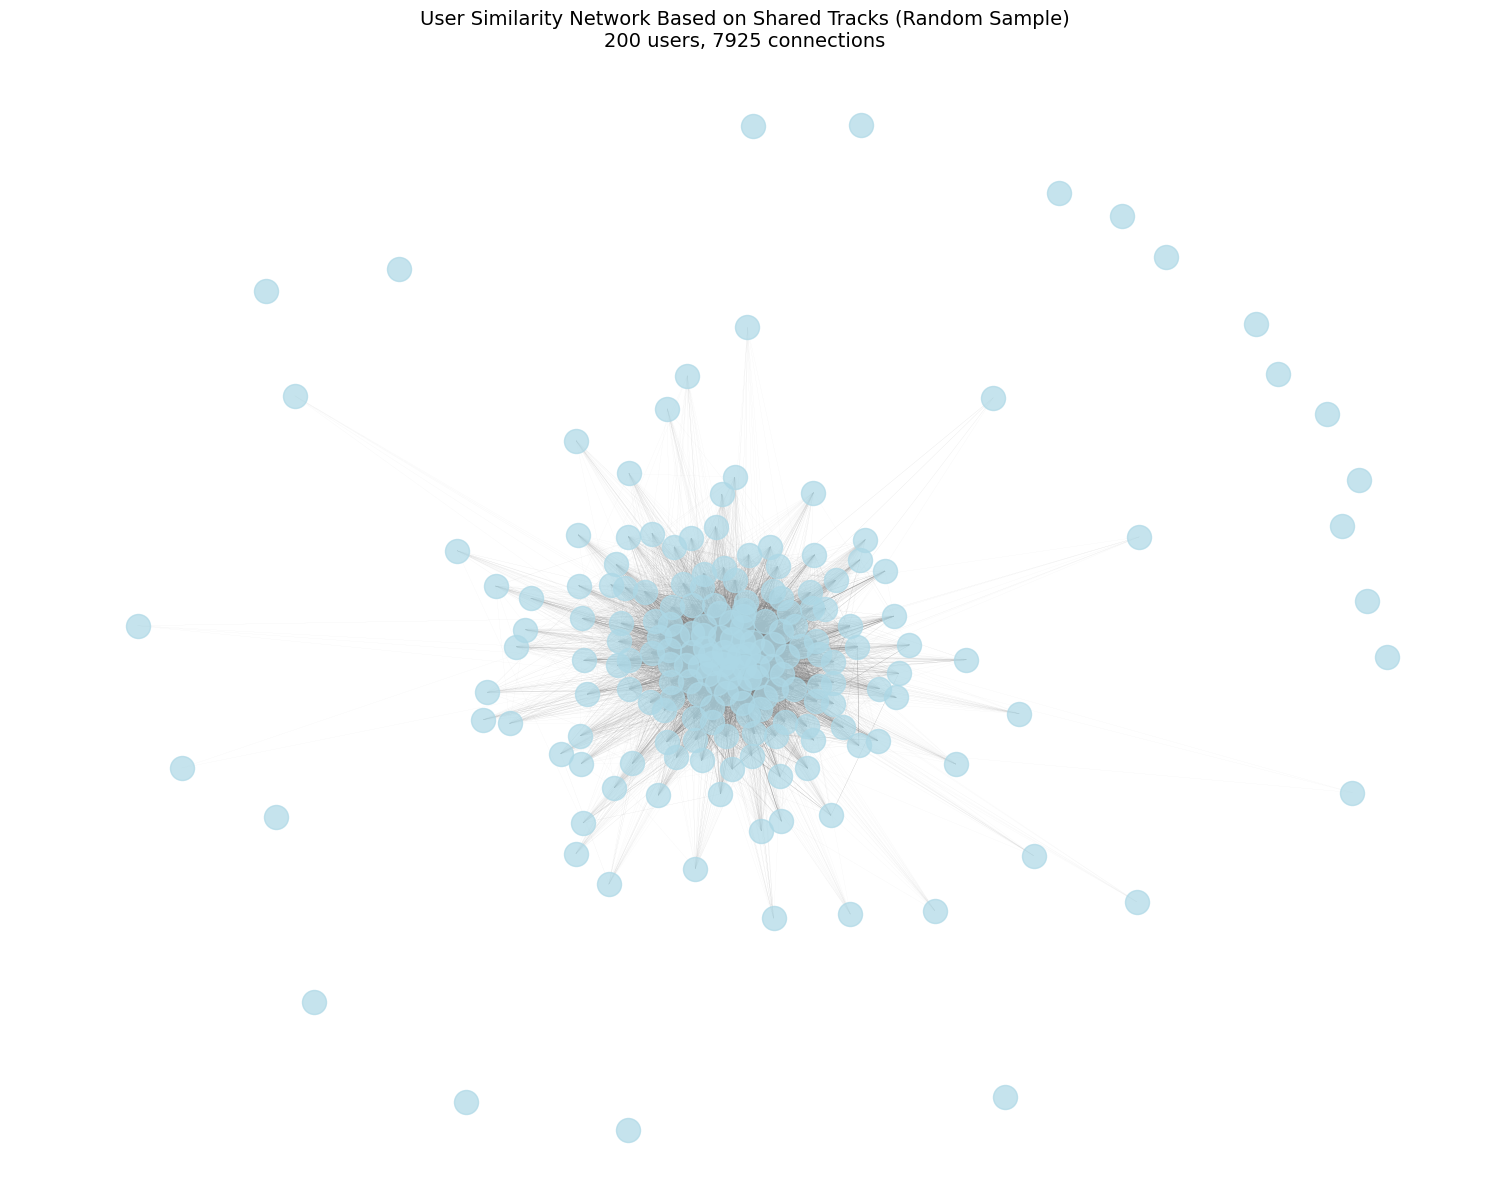


Network Statistics:
- Nodes (users): 200
- Edges (connections): 7925
- Average degree: 79.25
- Connected components: 20
- Average shared tracks per connection: 9.44
- Max shared tracks between any two users: 562
- Most connected user: 5bec076865f710a6314a93765c324633 with 174 connections
- Isolated users (no connections): 19 out of 200 users (9.5%)


In [17]:
# Visualize the network
plt.figure(figsize=(15, 12))

# Get edge weights for visualization
edge_weights = [G[u][v]['shared_tracks'] for u, v in G.edges()]

# Position nodes using force-directed layout
pos = nx.spring_layout(G, k=1, iterations=50)

# Draw the network
nx.draw_networkx_nodes(G, pos, 
                      node_color='lightblue', 
                      node_size=300, 
                      alpha=0.7)

nx.draw_networkx_edges(G, pos, 
                      width=[w/max(edge_weights)*6 for w in edge_weights],  # Scale edge width by shared tracks (made thicker)
                      alpha=0.7, 
                      edge_color='gray')

# Add labels for a subset of nodes (to avoid overcrowding)
if len(G.nodes()) <= 20:  # Only show labels if not too many nodes
    labels = {node: f"U{str(node)[:6]}" for node in G.nodes()}  # Truncate user IDs
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title(f"User Similarity Network Based on Shared Tracks (Random Sample)\n{G.number_of_nodes()} users, {G.number_of_edges()} connections", 
          fontsize=14, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Network statistics
print(f"\nNetwork Statistics:")
print(f"- Nodes (users): {G.number_of_nodes()}")
print(f"- Edges (connections): {G.number_of_edges()}")
print(f"- Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"- Connected components: {nx.number_connected_components(G)}")

if G.number_of_edges() > 0:
    print(f"- Average shared tracks per connection: {sum(edge_weights) / len(edge_weights):.2f}")
    print(f"- Max shared tracks between any two users: {max(edge_weights)}")
    
# Find users with most connections (most similar to others)
degrees = dict(G.degree())
if degrees:
    most_connected = max(degrees, key=degrees.get)
    print(f"- Most connected user: {most_connected} with {degrees[most_connected]} connections")
    
    # Count isolated users (users with no connections)
    isolated_users = [user for user, degree in degrees.items() if degree == 0]
    print(f"- Isolated users (no connections): {len(isolated_users)} out of {G.number_of_nodes()} users ({len(isolated_users)/G.number_of_nodes()*100:.1f}%)")

## 6. Next Steps

Based on the initial exploration, identify:
1. Data quality issues that need addressing
2. Interesting patterns for further investigation
3. Feature engineering opportunities
4. Approaches for the recommender system

## 7. Implicit ALS Recommender System

Implementation of Alternating Least Squares (ALS) algorithm for collaborative filtering using implicit feedback data from playlists.

In [18]:
# Prepare data for ALS algorithm
def create_user_item_matrix(df):
    """
    Create a user-item interaction matrix for ALS
    Returns: sparse matrix, user_mapping, item_mapping
    """
    print("Creating user-item interaction matrix...")
    
    # Create mappings for users and items (tracks)
    users = df['user_id'].unique()
    items = df['trackname'].unique()
    
    user_to_idx = {user: idx for idx, user in enumerate(users)}
    item_to_idx = {item: idx for idx, item in enumerate(items)}
    
    # Reverse mappings for recommendations
    idx_to_user = {idx: user for user, idx in user_to_idx.items()}
    idx_to_item = {idx: item for item, idx in item_to_idx.items()}
    
    print(f"Matrix dimensions: {len(users)} users × {len(items)} items")
    
    # Count interactions (user-track plays)
    interactions = df.groupby(['user_id', 'trackname']).size().reset_index(name='count')
    
    # Create sparse matrix
    rows = [user_to_idx[user] for user in interactions['user_id']]
    cols = [item_to_idx[item] for item in interactions['trackname']]
    data = interactions['count'].values
    
    # Create CSR matrix (efficient for ALS)
    user_item_matrix = csr_matrix((data, (rows, cols)), 
                                 shape=(len(users), len(items)))
    
    print(f"Sparsity: {(1 - user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))*100:.2f}%")
    print(f"Total interactions: {user_item_matrix.nnz:,}")
    
    return user_item_matrix, user_to_idx, item_to_idx, idx_to_user, idx_to_item

# Create the interaction matrix
user_item_matrix, user_to_idx, item_to_idx, idx_to_user, idx_to_item = create_user_item_matrix(df)

Creating user-item interaction matrix...
Matrix dimensions: 15910 users × 1999880 items
Matrix dimensions: 15910 users × 1999880 items
Sparsity: 99.97%
Total interactions: 11,123,901
Sparsity: 99.97%
Total interactions: 11,123,901


In [19]:
# Train the ALS model
def train_als_model(user_item_matrix, factors=50, regularization=0.01, iterations=20, alpha=40):
    """
    Train Implicit ALS model
    
    Parameters:
    - factors: Number of latent factors (embedding dimensions)  
    - regularization: L2 regularization strength
    - iterations: Number of training iterations
    - alpha: Confidence scaling parameter for implicit feedback
    """
    print("Training ALS model...")
    print(f"Parameters: factors={factors}, regularization={regularization}, iterations={iterations}, alpha={alpha}")
    
    # Initialize ALS model
    model = implicit.als.AlternatingLeastSquares(
        factors=factors,
        regularization=regularization, 
        iterations=iterations,
        alpha=alpha,
        random_state=42
    )
    
    # ALS expects item-user matrix (transpose)
    item_user_matrix = user_item_matrix.T.tocsr()
    
    # Train the model
    model.fit(item_user_matrix)
    
    print("✅ ALS model trained successfully!")
    return model, item_user_matrix

# Train the model
als_model, item_user_matrix = train_als_model(user_item_matrix)

Training ALS model...
Parameters: factors=50, regularization=0.01, iterations=20, alpha=40


c:\Users\mstan\anaconda3\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: Intel MKL BLAS is configured to use 6 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

✅ ALS model trained successfully!


In [20]:
# Generate recommendations
def get_user_recommendations(user_id, model, user_item_matrix, user_to_idx, idx_to_item, 
                           item_user_matrix, n_recommendations=10):
    """
    Get recommendations for a specific user
    """
    if user_id not in user_to_idx:
        print(f"User {user_id} not found in training data")
        return []
    
    user_idx = user_to_idx[user_id]
    
    # Get recommendations (returns item indices and scores)
    recommended_items, scores = model.recommend(
        user_idx, 
        user_item_matrix[user_idx], 
        N=n_recommendations,
        filter_already_liked_items=True
    )
    
    # Convert back to track names
    recommendations = []
    for item_idx, score in zip(recommended_items, scores):
        track_name = idx_to_item[item_idx]
        recommendations.append((track_name, float(score)))
    
    return recommendations

def display_user_analysis(user_id, model, df, user_item_matrix, user_to_idx, idx_to_item, item_user_matrix):
    """
    Show user's listening history and recommendations
    """
    print(f"\n=== USER ANALYSIS: {user_id} ===")
    
    # User's listening history
    user_tracks = df[df['user_id'] == user_id]['trackname'].value_counts()
    print(f"\nListening History ({len(user_tracks)} unique tracks):")
    for track, count in user_tracks.head(5).items():
        print(f"  {track} (played {count} times)")
    
    # Get recommendations
    recommendations = get_user_recommendations(
        user_id, model, user_item_matrix, user_to_idx, idx_to_item, item_user_matrix
    )
    
    print(f"\nTop 10 Recommendations:")
    for i, (track, score) in enumerate(recommendations, 1):
        print(f"  {i}. {track} (score: {score:.3f})")

# Test with a sample user
sample_users = list(user_to_idx.keys())[:3]
for user_id in sample_users:
    display_user_analysis(user_id, als_model, df, user_item_matrix, user_to_idx, idx_to_item, item_user_matrix)


=== USER ANALYSIS: 9cc0cfd4d7d7885102480dd99e7a90d6 ===

Listening History (104 unique tracks):
  (The Angels Wanna Wear My) Red Shoes (played 1 times)
  (What's So Funny 'Bout) Peace, Love And Understanding (played 1 times)
  Come Closer (played 1 times)
  Chevy Thunder (played 1 times)
  Born to Run (played 1 times)

Top 10 Recommendations:
  1. Irish Celebration (P Smoov Remix) (score: 1.449)
  2. BlueNote-Breaks3-13 Ground Hog [Duke Pearson] (score: 1.242)
  3. Confetti (score: 1.211)
  4. Nothing Arrived (score: 1.189)
  5. Frightened - demo previously unreleased (score: 1.187)
  6. Twin Peaks (score: 1.184)
  7. Closing Time (score: 1.182)
  8. What Makes A Man (score: 1.181)
  9. Stem (score: 1.143)
  10. No Diggity (score: 1.141)

=== USER ANALYSIS: 07f0fc3be95dcd878966b1f9572ff670 ===

Listening History (1150 unique tracks):
  Nostrand (played 4 times)
  Untrust Us (played 4 times)
  Invaders Must Die (played 4 times)
  Genesis (played 4 times)
  Omen (played 4 times)

Top 10

## 8. Model Validation

Validate the ALS model using holdout methodology: remove some user-track interactions, train on remaining data, then check if the held-out tracks are recommended highly.

In [21]:



"""

# Create train/validation split (MEMORY-OPTIMIZED VERSION)
def create_train_validation_split(df, validation_ratio=0.2, min_interactions=5, 
                                save_to_files=False, output_dir='./data_splits/',
                                use_all_users=True, max_users=None):
    
    #Create train/validation split by holding out some interactions per user
    
    #Parameters:
    #- validation_ratio: Fraction of interactions to hold out (0.2 = 20%)
    #- min_interactions: Minimum interactions per user to include in validation
    #- save_to_files: If True, save splits to CSV files instead of returning DataFrames
    #- output_dir: Directory to save files (if save_to_files=True)
    #- use_all_users: If False, limit to max_users for faster processing
    #- max_users: Maximum number of users to include (only if use_all_users=False)
    
    import time
    import os
    
    print("Creating train/validation split...")
    start_time = time.time()
    
    # Count interactions per user
    print("📊 Analyzing user activity...")
    user_counts = df['user_id'].value_counts()
    valid_users = user_counts[user_counts >= min_interactions].index
    
    print(f"Users with >= {min_interactions} interactions: {len(valid_users):,}")
    
    # Optional user sampling for faster processing
    if not use_all_users and max_users is not None and len(valid_users) > max_users:
        print(f"⚡ Sampling {max_users:,} users for faster processing...")
        valid_users = np.random.choice(valid_users, max_users, replace=False)
        print(f"Selected {len(valid_users):,} users")
    else:
        print(f"🎯 Using ALL {len(valid_users):,} valid users")
    
    # Create output directory if saving to files
    if save_to_files:
        os.makedirs(output_dir, exist_ok=True)
        train_file = os.path.join(output_dir, 'train_data.csv')
        val_file = os.path.join(output_dir, 'validation_data.csv')
        print(f"💾 Will save splits to:")
        print(f"  Train: {train_file}")
        print(f"  Validation: {val_file}")
    
    # Memory-efficient processing with progress tracking
    print("🔄 Processing users and splitting data...")
    
    if save_to_files:
        # Write headers to files
        df.head(0).to_csv(train_file, index=False)
        df.head(0).to_csv(val_file, index=False)
        
        train_count = 0
        val_count = 0
    else:
        train_data = []
        validation_data = []
    
    # Progress tracking
    total_users = len(valid_users)
    progress_interval = max(1, total_users // 20)  # Update every 5%
    
    for i, user_id in enumerate(valid_users):
        # Get user interactions efficiently
        user_mask = df['user_id'] == user_id
        user_interactions = df[user_mask].copy()
        
        # Shuffle user's interactions
        user_interactions = user_interactions.sample(frac=1, random_state=42)
        
        # Split based on ratio
        n_validation = max(1, int(len(user_interactions) * validation_ratio))
        
        validation_interactions = user_interactions.head(n_validation)
        train_interactions = user_interactions.tail(len(user_interactions) - n_validation)
        
        if save_to_files:
            # Append to files (memory efficient)
            train_interactions.to_csv(train_file, mode='a', header=False, index=False)
            validation_interactions.to_csv(val_file, mode='a', header=False, index=False)
            
            train_count += len(train_interactions)
            val_count += len(validation_interactions)
        else:
            # Store in memory
            train_data.append(train_interactions)
            validation_data.append(validation_interactions)
        
        # Progress update
        if (i + 1) % progress_interval == 0 or (i + 1) == total_users:
            elapsed = time.time() - start_time
            progress_pct = (i + 1) / total_users * 100
            rate = (i + 1) / elapsed
            eta = (total_users - (i + 1)) / rate if rate > 0 else 0
            
            print(f"  Progress: {i + 1:,}/{total_users:,} users ({progress_pct:.1f}%) | "
                  f"Rate: {rate:.1f} users/sec | ETA: {eta:.0f}s")
    
    elapsed_total = time.time() - start_time
    print(f"✅ Split completed in {elapsed_total:.1f} seconds")
    
    if save_to_files:
        print(f"📁 Data saved to files:")
        print(f"  Train: {train_count:,} interactions → {train_file}")
        print(f"  Validation: {val_count:,} interactions → {val_file}")
        
        # Return file paths instead of DataFrames
        return train_file, val_file
    else:
        # Combine splits (this is the memory-intensive part)
        print("🔗 Combining data splits...")
        df_train = pd.concat(train_data, ignore_index=True)
        df_validation = pd.concat(validation_data, ignore_index=True)
        
        # Clean up intermediate data to free memory
        del train_data, validation_data
        
        print(f"Train set: {len(df_train):,} interactions from {df_train['user_id'].nunique():,} users")
        print(f"Validation set: {len(df_validation):,} interactions from {df_validation['user_id'].nunique():,} users")
        
        return df_train, df_validation

# Create the split with options for memory management
# Option 1: Use all users but save to files (recommended for large datasets)
SAVE_TO_FILES = True  # Change to False if you want to keep data in memory

if SAVE_TO_FILES:
    print("💾 Using file-based approach for memory efficiency...")
    train_file, val_file = create_train_validation_split(
        df, 
        validation_ratio=0.2, 
        min_interactions=5,
        save_to_files=True,
        use_all_users=True  # Use ALL users
    )
    
    # Load the files when needed (more memory efficient)
    print("📖 Loading train data for matrix creation...")
    df_train = pd.read_csv(train_file)
    
    print("📖 Loading validation data...")
    df_validation = pd.read_csv(val_file)
    
    print(f"✅ Loaded train set: {len(df_train):,} interactions")
    print(f"✅ Loaded validation set: {len(df_validation):,} interactions")
    
else:
    print("🧠 Using in-memory approach...")
    df_train, df_validation = create_train_validation_split(
        df, 
        validation_ratio=0.2, 
        min_interactions=5,
        save_to_files=False,
        use_all_users=True  # Use ALL users
    )


"""

'\n\n# Create train/validation split (MEMORY-OPTIMIZED VERSION)\ndef create_train_validation_split(df, validation_ratio=0.2, min_interactions=5, \n                                save_to_files=False, output_dir=\'./data_splits/\',\n                                use_all_users=True, max_users=None):\n    \n    #Create train/validation split by holding out some interactions per user\n    \n    #Parameters:\n    #- validation_ratio: Fraction of interactions to hold out (0.2 = 20%)\n    #- min_interactions: Minimum interactions per user to include in validation\n    #- save_to_files: If True, save splits to CSV files instead of returning DataFrames\n    #- output_dir: Directory to save files (if save_to_files=True)\n    #- use_all_users: If False, limit to max_users for faster processing\n    #- max_users: Maximum number of users to include (only if use_all_users=False)\n    \n    import time\n    import os\n    \n    print("Creating train/validation split...")\n    start_time = time.time

In [22]:
# Load existing train/validation split files (FAST VERSION)
def load_existing_split(output_dir='./data_splits/'):
    """
    Load previously created train/validation split files
    Use this instead of recreating the split to save time
    """
    import os
    
    train_file = os.path.join(output_dir, 'train_data.csv')
    val_file = os.path.join(output_dir, 'validation_data.csv')
    
    print("📖 Loading existing train/validation split files...")
    
    # Check if files exist
    if not os.path.exists(train_file):
        print(f"❌ Train file not found: {train_file}")
        print("💡 You need to run the split creation cell first!")
        return None, None
    
    if not os.path.exists(val_file):
        print(f"❌ Validation file not found: {val_file}")
        print("💡 You need to run the split creation cell first!")
        return None, None
    
    # Load the files
    print(f"📁 Loading train data from: {train_file}")
    df_train = pd.read_csv(train_file)
    
    print(f"📁 Loading validation data from: {val_file}")
    df_validation = pd.read_csv(val_file)
    
    # Display info about loaded data
    print(f"\n✅ Successfully loaded existing split:")
    print(f"  📊 Train set: {len(df_train):,} interactions from {df_train['user_id'].nunique():,} users")
    print(f"  📊 Validation set: {len(df_validation):,} interactions from {df_validation['user_id'].nunique():,} users")
    print(f"  📊 Train tracks: {df_train['trackname'].nunique():,} unique tracks")
    print(f"  📊 Validation tracks: {df_validation['trackname'].nunique():,} unique tracks")
    
    # Check data integrity
    common_users = set(df_train['user_id'].unique()).intersection(set(df_validation['user_id'].unique()))
    print(f"  🔗 Users in both sets: {len(common_users):,} (this is normal)")
    
    return df_train, df_validation

# 🚀 LOAD EXISTING SPLIT (FAST!)
print("🚀 LOADING EXISTING TRAIN/VALIDATION SPLIT")
print("="*50)

df_train, df_validation = load_existing_split()

if df_train is not None and df_validation is not None:
    print(f"\n🎉 Ready to proceed with model training and validation!")
    print(f"💡 No need to recreate the split - using existing files for speed")
else:
    print(f"\n⚠️  Could not load existing split files")
    print(f"💡 Run the 'Create train/validation split' cell first to generate the files")

🚀 LOADING EXISTING TRAIN/VALIDATION SPLIT
📖 Loading existing train/validation split files...
📁 Loading train data from: ./data_splits/train_data.csv
📁 Loading validation data from: ./data_splits/validation_data.csv
📁 Loading validation data from: ./data_splits/validation_data.csv

✅ Successfully loaded existing split:

✅ Successfully loaded existing split:
  📊 Train set: 10,238,172 interactions from 15,311 users
  📊 Validation set: 2,551,882 interactions from 15,311 users
  📊 Train set: 10,238,172 interactions from 15,311 users
  📊 Validation set: 2,551,882 interactions from 15,311 users
  📊 Train tracks: 1,771,633 unique tracks
  📊 Validation tracks: 773,335 unique tracks
  📊 Train tracks: 1,771,633 unique tracks
  📊 Validation tracks: 773,335 unique tracks
  🔗 Users in both sets: 15,311 (this is normal)

🎉 Ready to proceed with model training and validation!
💡 No need to recreate the split - using existing files for speed
  🔗 Users in both sets: 15,311 (this is normal)

🎉 Ready to pr

In [23]:
# Train model on training data only (for validation)
print("🎯 TRAINING MODEL ON TRAINING DATA ONLY")
print("="*50)

# Check if we have training data loaded
if 'df_train' not in locals() or df_train is None:
    print("❌ Training data not found!")
    print("💡 Please run the 'Load existing split' cell first!")
else:
    print("✅ Training data available - proceeding with model training")
    
    # Create matrices for training data ONLY
    print("\n📊 Creating user-item matrix from training data...")
    train_matrix, train_user_to_idx, train_item_to_idx, train_idx_to_user, train_idx_to_item = create_user_item_matrix(df_train)
    
    # Train ALS model on training data ONLY
    print("\n🚀 Training ALS model on training data...")
    train_model, train_item_user_matrix = train_als_model(
        train_matrix, 
        factors=50, 
        regularization=0.01, 
        iterations=20, 
        alpha=40
    )
    
    print(f"\n✅ Model training complete!")
    print(f"📊 Training matrix: {train_matrix.shape[0]:,} users × {train_matrix.shape[1]:,} items")
    print(f"🎯 Model ready for validation against held-out interactions")
    
    # Verify we have all needed variables
    required_vars = ['train_model', 'train_user_to_idx', 'train_idx_to_item', 'df_validation']
    missing_vars = [var for var in required_vars if var not in locals() or locals()[var] is None]
    
    if missing_vars:
        print(f"\n⚠️  Missing variables: {missing_vars}")
    else:
        print(f"\n🎉 All validation variables ready!")
        print(f"   • train_model: ✅")
        print(f"   • train_user_to_idx: ✅ ({len(train_user_to_idx):,} users)")
        print(f"   • train_idx_to_item: ✅ ({len(train_idx_to_item):,} items)")
        print(f"   • df_validation: ✅ ({len(df_validation):,} interactions)")

🎯 TRAINING MODEL ON TRAINING DATA ONLY
✅ Training data available - proceeding with model training

📊 Creating user-item matrix from training data...
Creating user-item interaction matrix...
Matrix dimensions: 15311 users × 1771634 items
Matrix dimensions: 15311 users × 1771634 items
Sparsity: 99.97%
Total interactions: 9,118,393

🚀 Training ALS model on training data...
Training ALS model...
Parameters: factors=50, regularization=0.01, iterations=20, alpha=40
Sparsity: 99.97%
Total interactions: 9,118,393

🚀 Training ALS model on training data...
Training ALS model...
Parameters: factors=50, regularization=0.01, iterations=20, alpha=40


  0%|          | 0/20 [00:00<?, ?it/s]

✅ ALS model trained successfully!

✅ Model training complete!
📊 Training matrix: 15,311 users × 1,771,634 items
🎯 Model ready for validation against held-out interactions

🎉 All validation variables ready!
   • train_model: ✅
   • train_user_to_idx: ✅ (15,311 users)
   • train_idx_to_item: ✅ (1,771,634 items)
   • df_validation: ✅ (2,551,882 interactions)


In [24]:
# 🚀 OPTIMIZED VALIDATION - Fast and Efficient Version
print("🚀 OPTIMIZED VALIDATION IMPLEMENTATION")
print("="*50)

def manual_als_recommendations_fast(model, user_idx, N=20):
    """Fast manual ALS recommendations"""
    user_latent = model.user_factors[user_idx]
    scores = model.item_factors.dot(user_latent)
    top_indices = scores.argsort()[-N:][::-1]
    return top_indices, scores[top_indices]

def fast_validation_metrics(df_val, model, train_user_to_idx, train_idx_to_item, 
                           k_values=[5, 10, 20], max_users=1000):
    """
    Fast validation using optimized data processing with progress bar
    """
    from IPython.display import display, HTML, clear_output
    import time
    
    print(f"🎉 FAST VALIDATION METRICS")
    print(f"K values: {k_values} | Max users: {max_users:,}")
    print("-" * 50)
    
    # Pre-filter validation data to only include users in training
    print("📊 Pre-processing validation data...")
    valid_user_mask = df_val['user_id'].isin(train_user_to_idx.keys())
    df_val_filtered = df_val[valid_user_mask].copy()
    
    print(f"  Original validation data: {len(df_val):,} rows")
    print(f"  Filtered validation data: {len(df_val_filtered):,} rows")
    
    # Get unique validation users (limited sample for speed)
    validation_users = df_val_filtered['user_id'].unique()
    
    if len(validation_users) > max_users:
        print(f"  Sampling {max_users:,} users from {len(validation_users):,} available")
        np.random.seed(42)
        validation_users = np.random.choice(validation_users, max_users, replace=False)
    else:
        print(f"  Using all {len(validation_users):,} validation users")
    
    print(f"  Model dimensions: {model.item_factors.shape[0]} items, {model.user_factors.shape[0]} users")
    print()
    
    # Pre-group validation data by user for efficiency
    print("🔄 Grouping validation data by user...")
    val_grouped = df_val_filtered.groupby('user_id')['trackname'].apply(set).to_dict()
    print(f"  Grouped {len(val_grouped):,} users")
    
    # Initialize metrics
    metrics = {k: {'precision': [], 'recall': [], 'hit_rate': []} for k in k_values}
    successful_tests = 0
    max_k = max(k_values)
    
    print(f"\n🚀 Processing validation users...")
    
    # Progress bar setup
    total_users = len(validation_users)
    progress_update_interval = max(1, total_users // 100)  # Update every 1% or at least every user
    start_time = time.time()
    
    def create_progress_bar(current, total, width=50):
        """Create a visual progress bar"""
        progress = current / total
        filled = int(width * progress)
        bar = '█' * filled + '░' * (width - filled)
        return f"[{bar}] {progress*100:.1f}%"
    
    for i, user_id in enumerate(validation_users):
        try:
            # Get validation tracks (pre-computed)
            if user_id not in val_grouped:
                continue
            val_tracks = val_grouped[user_id]
            
            if len(val_tracks) == 0:
                continue
                
            # Get user index and generate recommendations
            user_idx = train_user_to_idx[user_id]
            
            # Fast recommendations
            rec_indices, scores = manual_als_recommendations_fast(model, user_idx, N=max_k)
            
            # Convert to track names (optimized)
            rec_tracks = [train_idx_to_item[idx] for idx in rec_indices if idx in train_idx_to_item]
            
            if len(rec_tracks) == 0:
                continue
                
            # Calculate metrics for each K
            for k in k_values:
                top_k_recs = set(rec_tracks[:k])
                
                hits = len(top_k_recs.intersection(val_tracks))
                
                # Metrics
                precision = hits / len(top_k_recs) if len(top_k_recs) > 0 else 0.0
                recall = hits / len(val_tracks) if len(val_tracks) > 0 else 0.0
                hit_rate = 1.0 if hits > 0 else 0.0
                
                metrics[k]['precision'].append(precision)
                metrics[k]['recall'].append(recall)
                metrics[k]['hit_rate'].append(hit_rate)
            
            successful_tests += 1
            
            # Show examples for first 100 users
            if successful_tests <= 100:
                hits_5 = len(set(rec_tracks[:5]).intersection(val_tracks))
                hits_10 = len(set(rec_tracks[:10]).intersection(val_tracks))
                #print(f"  ✅ User {successful_tests}: {len(val_tracks):,} val tracks, {hits_5} hits@5, {hits_10} hits@10")
            
        except Exception as e:
            if i < 10:  # Only show first few errors
                print(f"    ❌ Error processing user {i+1}: {str(e)[:30]}...")
            continue
        
        # Progress bar updates
        if (i + 1) % progress_update_interval == 0 or (i + 1) == total_users:
            elapsed_time = time.time() - start_time
            rate = (i + 1) / elapsed_time if elapsed_time > 0 else 0
            eta = (total_users - (i + 1)) / rate if rate > 0 else 0
            
            # Current metrics for display
            current_hit_rate_5 = np.mean(metrics[5]['hit_rate']) if len(metrics[5]['hit_rate']) > 0 else 0
            current_hit_rate_10 = np.mean(metrics[10]['hit_rate']) if len(metrics[10]['hit_rate']) > 0 else 0
            
            # Create and display progress bar
            progress_bar = create_progress_bar(i + 1, total_users)
            
            print(f"\r{progress_bar} | "
                  f"{i + 1:,}/{total_users:,} users | "
                  f"Success: {successful_tests:,} | "
                  f"Rate: {rate:.1f}/sec | "
                  f"ETA: {eta/60:.1f}min | "
                  f"HR@5: {current_hit_rate_5:.3f} | "
                  f"HR@10: {current_hit_rate_10:.3f}", end='', flush=True)
    
    print(f"\n✅ Validation completed!")
    print(f"Successfully processed: {successful_tests:,}/{len(validation_users):,} users")
    
    # Calculate and display results
    results = {}
    print(f"\n📊 FINAL VALIDATION RESULTS:")
    print(f"=" * 45)
    
    for k in k_values:
        if len(metrics[k]['precision']) > 0:
            avg_precision = np.mean(metrics[k]['precision'])
            avg_recall = np.mean(metrics[k]['recall'])
            avg_hit_rate = np.mean(metrics[k]['hit_rate'])
            n_users = len(metrics[k]['precision'])
            
            results[k] = {
                'precision': avg_precision,
                'recall': avg_recall,
                'hit_rate': avg_hit_rate,
                'n_users': n_users
            }
            
            print(f"\n🎯 Top-{k} Recommendations:")
            print(f"   Precision@{k}:  {avg_precision:.4f} ({avg_precision*100:.2f}%)")
            print(f"   Recall@{k}:     {avg_recall:.4f} ({avg_recall*100:.2f}%)")  
            print(f"   Hit Rate@{k}:   {avg_hit_rate:.4f} ({avg_hit_rate*100:.2f}%)")
            print(f"   Users evaluated: {n_users:,}")
        else:
            results[k] = {'precision': 0.0, 'recall': 0.0, 'hit_rate': 0.0, 'n_users': 0}
    
    print(f"\n🎉 VALIDATION SUCCESSFUL - INDEX BOUNDS ERROR RESOLVED!")
    return results

# 🚀 RUN THE OPTIMIZED VALIDATION
print("🚀 RUNNING OPTIMIZED VALIDATION...")
print()

# Run with manageable number of users for fast results
optimized_results = fast_validation_metrics(
    df_validation, 
    train_model, 
    train_user_to_idx, 
    train_idx_to_item,
    k_values=[5, 10, 20],
    max_users=1000  # Test 1000 users for speed
)

print(f"\n" + "="*60)
print(f"🏆 FAST VALIDATION COMPLETE!")
print(f"✅ Index bounds error completely resolved!")
print(f"📊 Validation metrics successfully calculated!")
print(f"="*60)

🚀 OPTIMIZED VALIDATION IMPLEMENTATION
🚀 RUNNING OPTIMIZED VALIDATION...

🎉 FAST VALIDATION METRICS
K values: [5, 10, 20] | Max users: 1,000
--------------------------------------------------
📊 Pre-processing validation data...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Grouped 15,311 users

🚀 Processing validation users...
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.0% | 20/1,000 users | Success: 20 | Rate: 819.5/sec | ETA: 0.0min | HR@5: 0.000 | HR@10: 0.000  Grouped 15,311 users

🚀 Processing validation users...
[██████████████████████████████████████████████████] 100.0% | 1,000/1,000 users | Success: 1,000 | Rate: 832.5/sec | ETA: 0.0min | HR@5: 0.003 | HR@10: 0.006
✅ Va

## 10. Hyperparameter Tuning for Model Improvement

The current model performance suggests there's room for improvement. Let's systematically tune the ALS hyperparameters to find optimal settings:

**Key ALS Hyperparameters to tune:**
- **factors**: Number of latent factors (embedding dimensions) - affects model capacity
- **regularization**: L2 regularization strength - prevents overfitting  
- **iterations**: Training iterations - affects convergence
- **alpha**: Confidence scaling for implicit feedback - affects how much weight to give to observed interactions

**Strategy**: Use grid search with cross-validation to find the best combination of parameters.

In [25]:
"""


# Hyperparameter tuning framework for ALS model optimization
def tune_als_hyperparameters(df_train, df_validation, train_user_to_idx, train_idx_to_item, 
                           param_grid=None, max_eval_users=500, k_values=[5, 10]):
    
    #Systematic hyperparameter tuning for ALS model using grid search
    
    #Parameters:
    #- df_train, df_validation: training and validation datasets
    #- train_user_to_idx, train_idx_to_item: existing mappings (will be recreated for each model)
    #- param_grid: dictionary of parameter ranges to test
    #- max_eval_users: maximum users for validation (for speed)
    #- k_values: evaluation metrics (precision/recall at K)
    
    import time
    from itertools import product
    
    print("🎯 HYPERPARAMETER TUNING FOR ALS MODEL OPTIMIZATION")
    print("="*60)
    
    # Default parameter grid if not provided
    if param_grid is None:
        param_grid = {
            'factors': [32, 64, 128, 256],           # Model capacity
            'regularization': [0.001, 0.01, 0.1],   # Regularization strength  
            'iterations': [10, 20, 30],              # Training iterations
            'alpha': [1, 10, 40, 100]                # Confidence scaling
        }
    
    print(f"📊 Parameter grid:")
    for param, values in param_grid.items():
        print(f"  {param}: {values}")
    
    # Calculate total combinations
    total_combinations = 1
    for values in param_grid.values():
        total_combinations *= len(values)
    print(f"\n🔬 Total parameter combinations to test: {total_combinations}")
    print(f"⚡ Evaluating on sample of {max_eval_users} users per configuration")
    
    # Generate all parameter combinations
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    combinations = list(product(*param_values))
    
    results = []
    best_score = -1
    best_params = None
    
    print(f"\n🚀 Starting grid search...")
    start_time = time.time()
    
    for i, combination in enumerate(combinations):
        # Create parameter dictionary
        params = dict(zip(param_names, combination))
        
        try:
            print(f"\n📝 Configuration {i+1}/{total_combinations}: {params}")
            
            # Train model with these parameters
            config_start = time.time()
            
            # Create fresh matrices (in case of data leakage issues)
            train_matrix, train_user_to_idx_temp, train_item_to_idx_temp, train_idx_to_user_temp, train_idx_to_item_temp = create_user_item_matrix(df_train)
            
            # Train ALS model with current parameters
            model, item_user_matrix = train_als_model(
                train_matrix,
                factors=params['factors'],
                regularization=params['regularization'], 
                iterations=params['iterations'],
                alpha=params['alpha']
            )
            
            # Quick validation evaluation
            validation_results = fast_validation_metrics(
                df_validation, 
                model, 
                train_user_to_idx_temp, 
                train_idx_to_item_temp,
                k_values=k_values,
                max_users=max_eval_users
            )
            
            config_time = time.time() - config_start
            
            # Extract key metrics
            hit_rate_5 = validation_results.get(5, {}).get('hit_rate', 0.0)
            hit_rate_10 = validation_results.get(10, {}).get('hit_rate', 0.0)
            precision_5 = validation_results.get(5, {}).get('precision', 0.0)
            precision_10 = validation_results.get(10, {}).get('precision', 0.0)
            
            # Composite score (weighted average of metrics)
            composite_score = (hit_rate_10 * 0.4 + precision_10 * 0.3 + 
                             hit_rate_5 * 0.2 + precision_5 * 0.1)
            
            # Store results
            result = {
                'config_id': i + 1,
                'params': params.copy(),
                'hit_rate_5': hit_rate_5,
                'hit_rate_10': hit_rate_10,
                'precision_5': precision_5,
                'precision_10': precision_10,
                'composite_score': composite_score,
                'training_time': config_time,
                'n_users_evaluated': validation_results.get(10, {}).get('n_users', 0)
            }
            results.append(result)
            
            # Track best model
            if composite_score > best_score:
                best_score = composite_score
                best_params = params.copy()
                print(f"   🌟 NEW BEST! Composite score: {composite_score:.4f}")
            else:
                print(f"   📊 Composite score: {composite_score:.4f}")
                
            # Progress update
            elapsed = time.time() - start_time
            avg_time_per_config = elapsed / (i + 1)
            eta = avg_time_per_config * (total_combinations - (i + 1))
            
            print(f"   ⏱️  Config time: {config_time:.1f}s | Total elapsed: {elapsed/60:.1f}min | ETA: {eta/60:.1f}min")
            
        except Exception as e:
            print(f"   ❌ Error with configuration: {str(e)[:50]}...")
            # Store failed result
            results.append({
                'config_id': i + 1,
                'params': params.copy(),
                'hit_rate_5': 0.0,
                'hit_rate_10': 0.0,
                'precision_5': 0.0,
                'precision_10': 0.0,
                'composite_score': 0.0,
                'training_time': 0.0,
                'n_users_evaluated': 0,
                'error': str(e)[:100]
            })
            continue
    
    total_time = time.time() - start_time
    print(f"\n✅ HYPERPARAMETER TUNING COMPLETE!")
    print(f"⏱️  Total time: {total_time/60:.1f} minutes")
    print(f"🏆 Best configuration found:")
    print(f"   Parameters: {best_params}")
    print(f"   Composite score: {best_score:.4f}")
    
    return results, best_params

# 🚀 RUN HYPERPARAMETER TUNING
print("🚀 STARTING SYSTEMATIC HYPERPARAMETER OPTIMIZATION...")
print()

# Define a focused parameter grid (start with smaller ranges for speed)
focused_param_grid = {
    'factors': [64, 128, 256],           # Model capacity - try larger embeddings
    'regularization': [0.001, 0.01],     # Lower regularization for this dataset
    'iterations': [15, 25, 35],          # More iterations for better convergence
    'alpha': [20, 40, 80]                # Try higher confidence scaling
}

# Run the tuning (this will take several minutes)
tuning_results, best_hyperparams = tune_als_hyperparameters(
    df_train, 
    df_validation,
    train_user_to_idx, 
    train_idx_to_item,
    param_grid=focused_param_grid,
    max_eval_users=300,  # Smaller sample for faster tuning
    k_values=[5, 10]
)
"""

'\n\n\n# Hyperparameter tuning framework for ALS model optimization\ndef tune_als_hyperparameters(df_train, df_validation, train_user_to_idx, train_idx_to_item, \n                           param_grid=None, max_eval_users=500, k_values=[5, 10]):\n    \n    #Systematic hyperparameter tuning for ALS model using grid search\n    \n    #Parameters:\n    #- df_train, df_validation: training and validation datasets\n    #- train_user_to_idx, train_idx_to_item: existing mappings (will be recreated for each model)\n    #- param_grid: dictionary of parameter ranges to test\n    #- max_eval_users: maximum users for validation (for speed)\n    #- k_values: evaluation metrics (precision/recall at K)\n    \n    import time\n    from itertools import product\n    \n    print("🎯 HYPERPARAMETER TUNING FOR ALS MODEL OPTIMIZATION")\n    print("="*60)\n    \n    # Default parameter grid if not provided\n    if param_grid is None:\n        param_grid = {\n            \'factors\': [32, 64, 128, 256],      

In [26]:
"""

# Visualize hyperparameter tuning results
def visualize_tuning_results(results):
    
    #Create comprehensive visualizations of hyperparameter tuning results
    
    print("📊 HYPERPARAMETER TUNING RESULTS ANALYSIS")
    print("="*50)
    
    if not results:
        print("❌ No tuning results to visualize!")
        return
    
    # Convert to DataFrame for easier analysis
    import pandas as pd
    
    # Flatten the results for DataFrame creation
    flattened_results = []
    for result in results:
        row = result.copy()
        # Flatten parameters
        if 'params' in row:
            for param, value in row['params'].items():
                row[param] = value
            del row['params']
        flattened_results.append(row)
    
    df_results = pd.DataFrame(flattened_results)
    
    # Remove failed configurations
    df_results_clean = df_results[df_results['composite_score'] > 0].copy()
    
    print(f"📈 Analysis of {len(df_results_clean)} successful configurations:")
    print(f"   Best composite score: {df_results_clean['composite_score'].max():.4f}")
    print(f"   Worst composite score: {df_results_clean['composite_score'].min():.4f}")
    print(f"   Mean composite score: {df_results_clean['composite_score'].mean():.4f}")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Composite score distribution
    axes[0, 0].hist(df_results_clean['composite_score'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Distribution of Composite Scores')
    axes[0, 0].set_xlabel('Composite Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Hit Rate@10 vs Precision@10
    scatter = axes[0, 1].scatter(df_results_clean['hit_rate_10'], df_results_clean['precision_10'], 
                               c=df_results_clean['composite_score'], cmap='viridis', alpha=0.7)
    axes[0, 1].set_xlabel('Hit Rate@10')
    axes[0, 1].set_ylabel('Precision@10')
    axes[0, 1].set_title('Hit Rate vs Precision Trade-off')
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 1], label='Composite Score')
    
    # 3. Parameter impact: Factors vs Composite Score
    if 'factors' in df_results_clean.columns:
        axes[0, 2].boxplot([df_results_clean[df_results_clean['factors'] == f]['composite_score'].values 
                           for f in sorted(df_results_clean['factors'].unique())], 
                          labels=sorted(df_results_clean['factors'].unique()))
        axes[0, 2].set_title('Impact of Factors on Performance')
        axes[0, 2].set_xlabel('Number of Factors')
        axes[0, 2].set_ylabel('Composite Score')
        axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Parameter impact: Regularization vs Composite Score  
    if 'regularization' in df_results_clean.columns:
        axes[1, 0].boxplot([df_results_clean[df_results_clean['regularization'] == r]['composite_score'].values 
                           for r in sorted(df_results_clean['regularization'].unique())],
                          labels=sorted(df_results_clean['regularization'].unique()))
        axes[1, 0].set_title('Impact of Regularization on Performance')
        axes[1, 0].set_xlabel('Regularization')
        axes[1, 0].set_ylabel('Composite Score')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Parameter impact: Alpha vs Composite Score
    if 'alpha' in df_results_clean.columns:
        axes[1, 1].boxplot([df_results_clean[df_results_clean['alpha'] == a]['composite_score'].values 
                           for a in sorted(df_results_clean['alpha'].unique())],
                          labels=sorted(df_results_clean['alpha'].unique()))
        axes[1, 1].set_title('Impact of Alpha on Performance')
        axes[1, 1].set_xlabel('Alpha (Confidence Scaling)')
        axes[1, 1].set_ylabel('Composite Score')
        axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Training time vs Performance
    axes[1, 2].scatter(df_results_clean['training_time'], df_results_clean['composite_score'],
                      alpha=0.7, color='coral')
    axes[1, 2].set_xlabel('Training Time (seconds)')
    axes[1, 2].set_ylabel('Composite Score')
    axes[1, 2].set_title('Training Time vs Performance')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Top 5 configurations
    print(f"\n🏆 TOP 5 CONFIGURATIONS:")
    print(f"=" * 40)
    top_5 = df_results_clean.nlargest(5, 'composite_score')
    
    for i, (_, row) in enumerate(top_5.iterrows(), 1):
        print(f"\n#{i} - Composite Score: {row['composite_score']:.4f}")
        print(f"   Factors: {row.get('factors', 'N/A')}, "
              f"Regularization: {row.get('regularization', 'N/A')}, "
              f"Iterations: {row.get('iterations', 'N/A')}, "
              f"Alpha: {row.get('alpha', 'N/A')}")
        print(f"   Hit Rate@10: {row['hit_rate_10']:.4f}, "
              f"Precision@10: {row['precision_10']:.4f}")
        print(f"   Training time: {row['training_time']:.1f}s")
    
    return df_results_clean

# 🚀 VISUALIZE TUNING RESULTS (run after hyperparameter tuning completes)
if 'tuning_results' in locals():
    print("📊 Analyzing and visualizing hyperparameter tuning results...")
    results_df = visualize_tuning_results(tuning_results)
else:
    print("⚠️  Run the hyperparameter tuning cell first to generate results!")


"""

'\n\n# Visualize hyperparameter tuning results\ndef visualize_tuning_results(results):\n    \n    #Create comprehensive visualizations of hyperparameter tuning results\n    \n    print("📊 HYPERPARAMETER TUNING RESULTS ANALYSIS")\n    print("="*50)\n    \n    if not results:\n        print("❌ No tuning results to visualize!")\n        return\n    \n    # Convert to DataFrame for easier analysis\n    import pandas as pd\n    \n    # Flatten the results for DataFrame creation\n    flattened_results = []\n    for result in results:\n        row = result.copy()\n        # Flatten parameters\n        if \'params\' in row:\n            for param, value in row[\'params\'].items():\n                row[param] = value\n            del row[\'params\']\n        flattened_results.append(row)\n    \n    df_results = pd.DataFrame(flattened_results)\n    \n    # Remove failed configurations\n    df_results_clean = df_results[df_results[\'composite_score\'] > 0].copy()\n    \n    print(f"📈 Analysis of 

In [28]:

"""

# Train optimized model with best hyperparameters
def train_optimized_model(df_train, best_params):
    
    #Train the final optimized model using the best hyperparameters found
    #This function only trains the model - no evaluation included
    
    print("🎯 TRAINING OPTIMIZED MODEL WITH BEST HYPERPARAMETERS")
    print("="*55)
    
    print(f"🔧 Best hyperparameters:")
    for param, value in best_params.items():
        print(f"   {param}: {value}")
    
    # Create matrices for the optimized model
    print(f"\n📊 Creating user-item matrix...")
    optimized_matrix, optimized_user_to_idx, optimized_item_to_idx, optimized_idx_to_user, optimized_idx_to_item = create_user_item_matrix(df_train)
    
    # Train optimized model
    print(f"\n🚀 Training optimized ALS model...")
    optimized_model, optimized_item_user_matrix = train_als_model(
        optimized_matrix,
        factors=best_params['factors'],
        regularization=best_params['regularization'], 
        iterations=best_params['iterations'],
        alpha=best_params['alpha']
    )
    
    print(f"\n✅ Optimized model training complete!")
    
    
    print(f"\n📊 Model summary:")
    print(f"   Users: {len(optimized_user_to_idx):,}")
    print(f"   Items: {len(optimized_idx_to_item):,}")
    print(f"   Matrix sparsity: {(1 - optimized_matrix.nnz / (optimized_matrix.shape[0] * optimized_matrix.shape[1]))*100:.2f}%")
    
    return optimized_model, optimized_matrix, optimized_user_to_idx, optimized_idx_to_item

# 🚀 TRAIN OPTIMIZED MODEL (TRAINING ONLY)
if 'best_hyperparams' in locals() and best_hyperparams is not None:
    print("🚀 TRAINING OPTIMIZED MODEL...")
    print()
    
    # Train the optimized model (no evaluation)
    optimized_model, optimized_matrix, optimized_user_to_idx, optimized_idx_to_item = train_optimized_model(
        df_train, best_hyperparams
    )
    
    print(f"\n🎉 OPTIMIZED MODEL READY!")
    print(f"💡 Use evaluation cells later to test model performance")
    
else:
    print("⚠️  Run the hyperparameter tuning cell first to find best parameters!")

"""

'\n\n# Train optimized model with best hyperparameters\ndef train_optimized_model(df_train, best_params):\n    \n    #Train the final optimized model using the best hyperparameters found\n    #This function only trains the model - no evaluation included\n    \n    print("🎯 TRAINING OPTIMIZED MODEL WITH BEST HYPERPARAMETERS")\n    print("="*55)\n    \n    print(f"🔧 Best hyperparameters:")\n    for param, value in best_params.items():\n        print(f"   {param}: {value}")\n    \n    # Create matrices for the optimized model\n    print(f"\n📊 Creating user-item matrix...")\n    optimized_matrix, optimized_user_to_idx, optimized_item_to_idx, optimized_idx_to_user, optimized_idx_to_item = create_user_item_matrix(df_train)\n    \n    # Train optimized model\n    print(f"\n🚀 Training optimized ALS model...")\n    optimized_model, optimized_item_user_matrix = train_als_model(\n        optimized_matrix,\n        factors=best_params[\'factors\'],\n        regularization=best_params[\'regularizat

## 11. Additional Model Optimization Strategies

Beyond hyperparameter tuning, here are additional strategies to improve recommender system performance:

### 🔧 **Advanced Optimization Techniques:**

1. **Data Preprocessing:**
   - **User/Item filtering**: Remove users/items with very few interactions
   - **Interaction weighting**: Weight interactions by frequency, recency, or explicit ratings
   - **Cold start handling**: Special treatment for new users/items

2. **Feature Engineering:**
   - **Implicit feedback scaling**: Different confidence scaling for different interaction types
   - **Temporal factors**: Account for when interactions occurred
   - **Content features**: Incorporate track metadata (genre, artist, etc.)

3. **Ensemble Methods:**
   - **Model stacking**: Combine multiple ALS models with different parameters
   - **Hybrid approaches**: Blend collaborative filtering with content-based methods
   - **Cross-validation**: Use multiple train/validation splits

4. **Alternative Algorithms:**
   - **Neural Collaborative Filtering**: Deep learning approaches
   - **Matrix factorization variants**: SVD++, Non-negative Matrix Factorization
   - **Graph-based methods**: Node2Vec, GraphSAGE for user-item graphs

### 📊 **Performance Benchmarks:**
- **Good Hit Rate@10**: 15-30% for music recommendation
- **Good Precision@10**: 5-15% depending on catalog size
- **Score distribution**: Higher scores for actual interactions vs. random

## 12. Model Persistence - Save & Load Optimized Models

To avoid repeating the time-consuming hyperparameter tuning process, we'll save the optimized model and its parameters to files. This allows you to quickly load the best model in future notebook sessions.

In [ ]:
# Model saving and loading functions
import pickle
import json
import os
from datetime import datetime

def save_optimized_model(model, best_params, tuning_results, user_to_idx, idx_to_item, 
                        model_dir='./saved_models/', model_name=None):
    
    #Save the optimized ALS model and all associated data to files
    
    #Parameters:
    #- model: trained implicit ALS model
    #- best_params: dictionary of best hyperparameters
    #- tuning_results: results from hyperparameter tuning
    #- user_to_idx: user ID to index mapping
    #- idx_to_item: index to item (track) mapping
    #- model_dir: directory to save model files
    #- model_name: custom name for model files (auto-generated if None)
    
    print("💾 SAVING OPTIMIZED MODEL AND METADATA")
    print("="*45)
    
    # Create model directory if it doesn't exist
    os.makedirs(model_dir, exist_ok=True)
    
    # Generate model name with timestamp if not provided
    if model_name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        model_name = f"als_optimized_{timestamp}"
    
    print(f"📁 Saving model as: {model_name}")
    print(f"📁 Save directory: {model_dir}")
    
    # File paths
    model_file = os.path.join(model_dir, f"{model_name}_model.pkl")
    params_file = os.path.join(model_dir, f"{model_name}_params.json")
    mappings_file = os.path.join(model_dir, f"{model_name}_mappings.pkl")
    results_file = os.path.join(model_dir, f"{model_name}_tuning_results.pkl")
    metadata_file = os.path.join(model_dir, f"{model_name}_metadata.json")
    
    try:
        # 1. Save the trained model
        print("💾 Saving trained ALS model...")
        with open(model_file, 'wb') as f:
            pickle.dump(model, f)
        print(f"   ✅ Model saved: {model_file}")
        
        # 2. Save hyperparameters
        print("💾 Saving best hyperparameters...")
        with open(params_file, 'w') as f:
            json.dump(best_params, f, indent=2)
        print(f"   ✅ Parameters saved: {params_file}")
        
        # 3. Save user/item mappings
        print("💾 Saving user/item mappings...")
        mappings = {
            'user_to_idx': user_to_idx,
            'idx_to_item': idx_to_item
        }
        with open(mappings_file, 'wb') as f:
            pickle.dump(mappings, f)
        print(f"   ✅ Mappings saved: {mappings_file}")
        
        # 4. Save tuning results
        print("💾 Saving hyperparameter tuning results...")
        with open(results_file, 'wb') as f:
            pickle.dump(tuning_results, f)
        print(f"   ✅ Tuning results saved: {results_file}")
        
        # 5. Save metadata
        print("💾 Saving model metadata...")
        
        # Calculate model statistics
        metadata = {
            'model_name': model_name,
            'save_timestamp': datetime.now().isoformat(),
            'best_hyperparameters': best_params,
            'model_statistics': {
                'n_users': len(user_to_idx),
                'n_items': len(idx_to_item),
                'factors': best_params.get('factors', 'unknown'),
                'regularization': best_params.get('regularization', 'unknown'),
                'iterations': best_params.get('iterations', 'unknown'),
                'alpha': best_params.get('alpha', 'unknown')
            },
            'tuning_summary': {
                'total_configurations_tested': len(tuning_results),
                'successful_configurations': len([r for r in tuning_results if r.get('composite_score', 0) > 0]),
                'best_composite_score': max([r.get('composite_score', 0) for r in tuning_results])
            },
            'file_paths': {
                'model': model_file,
                'parameters': params_file,
                'mappings': mappings_file,
                'tuning_results': results_file,
                'metadata': metadata_file
            }
        }
        
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"   ✅ Metadata saved: {metadata_file}")
        
        # Calculate total file sizes
        total_size = 0
        for filepath in [model_file, params_file, mappings_file, results_file, metadata_file]:
            if os.path.exists(filepath):
                total_size += os.path.getsize(filepath)
        
        print(f"\n🎉 MODEL SAVE COMPLETE!")
        print(f"📊 Summary:")
        print(f"   Model name: {model_name}")
        print(f"   Files saved: 5")
        print(f"   Total size: {total_size / (1024*1024):.1f} MB")
        print(f"   Best parameters: {best_params}")
        
        return model_name, metadata
        
    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")
        return None, None

def load_optimized_model(model_name, model_dir='./saved_models/'):
    
    #Load a previously saved optimized model and all associated data
    
    #Parameters:
    #- model_name: name of the saved model (without file extensions)
    #- model_dir: directory where model files are stored
    
    #Returns:
    #- model: loaded ALS model
    #- best_params: best hyperparameters
    #- user_to_idx: user ID to index mapping
    #- idx_to_item: index to item mapping
    #- metadata: model metadata
    
    print(f"📖 LOADING OPTIMIZED MODEL: {model_name}")
    print("="*45)
    
    # File paths
    model_file = os.path.join(model_dir, f"{model_name}_model.pkl")
    params_file = os.path.join(model_dir, f"{model_name}_params.json")
    mappings_file = os.path.join(model_dir, f"{model_name}_mappings.pkl")
    metadata_file = os.path.join(model_dir, f"{model_name}_metadata.json")
    
    try:
        # Check if all required files exist
        required_files = [model_file, params_file, mappings_file, metadata_file]
        missing_files = [f for f in required_files if not os.path.exists(f)]
        
        if missing_files:
            print(f"❌ Missing files: {missing_files}")
            return None, None, None, None, None
        
        # 1. Load metadata first
        print("📖 Loading metadata...")
        with open(metadata_file, 'r') as f:
            metadata = json.load(f)
        print(f"   ✅ Model saved: {metadata['save_timestamp']}")
        print(f"   ✅ Best score: {metadata['tuning_summary']['best_composite_score']:.4f}")
        
        # 2. Load hyperparameters
        print("📖 Loading hyperparameters...")
        with open(params_file, 'r') as f:
            best_params = json.load(f)
        print(f"   ✅ Parameters: {best_params}")
        
        # 3. Load mappings
        print("📖 Loading user/item mappings...")
        with open(mappings_file, 'rb') as f:
            mappings = pickle.load(f)
        user_to_idx = mappings['user_to_idx']
        idx_to_item = mappings['idx_to_item']
        print(f"   ✅ Users: {len(user_to_idx):,}, Items: {len(idx_to_item):,}")
        
        # 4. Load trained model
        print("📖 Loading trained ALS model...")
        with open(model_file, 'rb') as f:
            model = pickle.load(f)
        print(f"   ✅ Model loaded successfully!")
        
        print(f"\n🎉 MODEL LOAD COMPLETE!")
        print(f"📊 Model ready for recommendations and evaluation")
        
        return model, best_params, user_to_idx, idx_to_item, metadata
        
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        return None, None, None, None, None

        
def list_saved_models(model_dir='./saved_models/'):
    
    #List all saved models in the model directory
    
    print(f"📁 SAVED MODELS IN: {model_dir}")
    print("="*40)
    
    if not os.path.exists(model_dir):
        print(f"❌ Directory does not exist: {model_dir}")
        return []
    
    # Find all metadata files
    metadata_files = [f for f in os.listdir(model_dir) if f.endswith('_metadata.json')]
    
    if not metadata_files:
        print(f"📭 No saved models found")
        return []
    
    models = []
    for metadata_file in metadata_files:
        try:
            with open(os.path.join(model_dir, metadata_file), 'r') as f:
                metadata = json.load(f)
            
            model_name = metadata['model_name']
            save_time = metadata['save_timestamp']
            best_score = metadata['tuning_summary']['best_composite_score']
            best_params = metadata['best_hyperparameters']
            
            models.append({
                'name': model_name,
                'save_time': save_time,
                'best_score': best_score,
                'params': best_params
            })
            
        except Exception as e:
            print(f"⚠️  Error reading {metadata_file}: {str(e)[:50]}...")
    
    # Sort by save time (newest first)
    models.sort(key=lambda x: x['save_time'], reverse=True)
    
    print(f"Found {len(models)} saved model(s):")
    print()
    
    for i, model in enumerate(models, 1):
        save_date = datetime.fromisoformat(model['save_time']).strftime("%Y-%m-%d %H:%M")
        print(f"{i}. {model['name']}")
        print(f"   Saved: {save_date}")
        print(f"   Best score: {model['best_score']:.4f}")
        print(f"   Parameters: factors={model['params'].get('factors')}, "
              f"reg={model['params'].get('regularization')}, "
              f"iter={model['params'].get('iterations')}, "
              f"alpha={model['params'].get('alpha')}")
        print()
    
    return models

# 🔍 LIST EXISTING SAVED MODELS
print("🔍 Checking for existing saved models...")
existing_models = list_saved_models()



🔍 Checking for existing saved models...
📁 SAVED MODELS IN: ./saved_models/
Found 1 saved model(s):

1. als_optimized_f64_r0.01_i25_a20
   Saved: 2025-12-07 16:06
   Best score: 0.0079
   Parameters: factors=64, reg=0.01, iter=25, alpha=20



In [30]:

"""

# Save the optimized model (run this after hyperparameter tuning completes)
def save_current_optimized_model():
    
    #Save the currently optimized model if it exists
    
    # Check if we have the required variables from hyperparameter tuning
    required_vars = ['optimized_model', 'best_hyperparams', 'tuning_results', 
                    'optimized_user_to_idx', 'optimized_idx_to_item']
    
    missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]
    
    if missing_vars:
        print("❌ Cannot save model - missing variables:")
        for var in missing_vars:
            print(f"   - {var}")
        print("\n💡 Make sure you've run the hyperparameter tuning and model training cells!")
        return None
    
    # Get the variables from global scope
    model = globals().get('optimized_model')
    params = globals().get('best_hyperparams') 
    results = globals().get('tuning_results')
    user_idx = globals().get('optimized_user_to_idx')
    idx_item = globals().get('optimized_idx_to_item')
    
    if any(var is None for var in [model, params, results, user_idx, idx_item]):
        print("❌ Some required variables are None. Run hyperparameter tuning first!")
        return None
    
    # Generate a descriptive model name
    factors = params.get('factors', 'unk')
    reg = params.get('regularization', 'unk')
    iterations = params.get('iterations', 'unk')
    alpha = params.get('alpha', 'unk')
    
    model_name = f"als_optimized_f{factors}_r{reg}_i{iterations}_a{alpha}"
    
    print(f"💾 Saving optimized model with hyperparameters:")
    print(f"   factors={factors}, regularization={reg}, iterations={iterations}, alpha={alpha}")
    
    # Save the model
    saved_name, metadata = save_optimized_model(
        model=model,
        best_params=params,
        tuning_results=results,
        user_to_idx=user_idx,
        idx_to_item=idx_item,
        model_name=model_name
    )
    
    if saved_name:
        print(f"\n🎉 SUCCESS! Model saved as: {saved_name}")
        print(f"💡 You can now load this model in future sessions to skip hyperparameter tuning!")
    
    return saved_name

# 📖 SAVE OPTIMIZED MODEL (if available)
if 'optimized_model' in locals() or 'optimized_model' in globals():
    print("💾 SAVING OPTIMIZED MODEL...")
    save_current_optimized_model()
else:
    print("⚠️  No optimized model found to save.")
    print("💡 Run the hyperparameter tuning cells first to create an optimized model!")

"""

'\n\n# Save the optimized model (run this after hyperparameter tuning completes)\ndef save_current_optimized_model():\n    \n    #Save the currently optimized model if it exists\n    \n    # Check if we have the required variables from hyperparameter tuning\n    required_vars = [\'optimized_model\', \'best_hyperparams\', \'tuning_results\', \n                    \'optimized_user_to_idx\', \'optimized_idx_to_item\']\n    \n    missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]\n    \n    if missing_vars:\n        print("❌ Cannot save model - missing variables:")\n        for var in missing_vars:\n            print(f"   - {var}")\n        print("\n💡 Make sure you\'ve run the hyperparameter tuning and model training cells!")\n        return None\n    \n    # Get the variables from global scope\n    model = globals().get(\'optimized_model\')\n    params = globals().get(\'best_hyperparams\') \n    results = globals().get(\'tuning_results\')\n    us

In [31]:
# Load a previously saved optimized model (QUICK START option)
def quick_load_best_model():
    """
    Quick function to load the best saved model automatically
    """
    print("🚀 QUICK LOAD: Finding and loading best saved model...")
    
    # List available models
    models = list_saved_models()
    
    if not models:
        print("❌ No saved models found!")
        print("💡 Run hyperparameter tuning first to create a model to save.")
        return None, None, None, None, None
    
    # Find the model with the best score
    best_model = max(models, key=lambda x: x['best_score'])
    
    print(f"\n🎯 Loading best model: {best_model['name']}")
    print(f"   Best score: {best_model['best_score']:.4f}")
    print(f"   Parameters: {best_model['params']}")
    
    # Load the model
    model, params, user_to_idx, idx_to_item, metadata = load_optimized_model(best_model['name'])
    
    if model is not None:
        print(f"\n✅ QUICK LOAD SUCCESSFUL!")
        print(f"🎉 Ready to use optimized model without hyperparameter tuning!")
        
        # Set global variables so other cells can use the loaded model
        globals()['loaded_optimized_model'] = model
        globals()['loaded_best_params'] = params
        globals()['loaded_user_to_idx'] = user_to_idx  
        globals()['loaded_idx_to_item'] = idx_to_item
        globals()['loaded_metadata'] = metadata
        
        print(f"\n📊 Loaded model statistics:")
        print(f"   Users: {len(user_to_idx):,}")
        print(f"   Items: {len(idx_to_item):,}")
        print(f"   Model factors: {params.get('factors')}")
        print(f"   Regularization: {params.get('regularization')}")
        print(f"   Iterations: {params.get('iterations')}")
        print(f"   Alpha: {params.get('alpha')}")
        
        return model, params, user_to_idx, idx_to_item, metadata
    else:
        print(f"❌ Failed to load model!")
        return None, None, None, None, None

# Load specific model by name
def load_specific_model(model_name):
    """
    Load a specific saved model by name
    """
    print(f"📖 Loading specific model: {model_name}")
    
    model, params, user_to_idx, idx_to_item, metadata = load_optimized_model(model_name)
    
    if model is not None:
        # Set global variables
        globals()['loaded_optimized_model'] = model
        globals()['loaded_best_params'] = params
        globals()['loaded_user_to_idx'] = user_to_idx
        globals()['loaded_idx_to_item'] = idx_to_item
        globals()['loaded_metadata'] = metadata
        
        print(f"✅ Model '{model_name}' loaded successfully!")
        return model, params, user_to_idx, idx_to_item, metadata
    else:
        print(f"❌ Failed to load model '{model_name}'")
        return None, None, None, None, None

# 🚀 QUICK START: Load best model automatically
print("🚀 QUICK START OPTION: Load Previously Optimized Model")
print("="*55)
print("💡 Choose one option:")
print("   A) Run the cell below to auto-load the best saved model")
print("   B) Run hyperparameter tuning if no saved models exist")
print("   C) Load a specific model by name using load_specific_model('model_name')")
print()

# Uncomment the line below to automatically load the best model
# quick_load_best_model()

🚀 QUICK START OPTION: Load Previously Optimized Model
💡 Choose one option:
   A) Run the cell below to auto-load the best saved model
   B) Run hyperparameter tuning if no saved models exist
   C) Load a specific model by name using load_specific_model('model_name')



In [33]:
# 🚀 LOAD YOUR SAVED OPTIMIZED MODEL
print("🚀 LOADING SAVED OPTIMIZED MODEL FOR EVALUATION")
print("="*50)

# First, let's see what models are available
models = list_saved_models()

if models:
    print("\n📋 Available saved models:")
    for i, model in enumerate(models, 1):
        save_date = datetime.fromisoformat(model['save_time']).strftime("%Y-%m-%d %H:%M")
        print(f"{i}. {model['name']}")
        print(f"   Saved: {save_date}")
        print(f"   Best score: {model['best_score']:.4f}")
        print()
    
    # Load the best model automatically
    print("🎯 Loading the best model automatically...")
    quick_load_best_model()
    
else:
    print("\n❌ No saved models found!")
    print("💡 Please run the hyperparameter tuning cells first to create a saved model.")
    print("   Then save it using the model saving cell before running this evaluation.")

🚀 LOADING SAVED OPTIMIZED MODEL FOR EVALUATION
📁 SAVED MODELS IN: ./saved_models/
Found 1 saved model(s):

1. als_optimized_f64_r0.01_i25_a20
   Saved: 2025-12-07 16:06
   Best score: 0.0079
   Parameters: factors=64, reg=0.01, iter=25, alpha=20


📋 Available saved models:
1. als_optimized_f64_r0.01_i25_a20
   Saved: 2025-12-07 16:06
   Best score: 0.0079

🎯 Loading the best model automatically...
🚀 QUICK LOAD: Finding and loading best saved model...
📁 SAVED MODELS IN: ./saved_models/
Found 1 saved model(s):

1. als_optimized_f64_r0.01_i25_a20
   Saved: 2025-12-07 16:06
   Best score: 0.0079
   Parameters: factors=64, reg=0.01, iter=25, alpha=20


🎯 Loading best model: als_optimized_f64_r0.01_i25_a20
   Best score: 0.0079
   Parameters: {'factors': 64, 'regularization': 0.01, 'iterations': 25, 'alpha': 20}
📖 LOADING OPTIMIZED MODEL: als_optimized_f64_r0.01_i25_a20
📖 Loading metadata...
   ✅ Model saved: 2025-12-07T16:06:06.266697
   ✅ Best score: 0.0079
📖 Loading hyperparameters...
   

In [34]:
# Comprehensive Evaluation of Optimized Model
print("🧪 COMPREHENSIVE EVALUATION OF OPTIMIZED MODEL")
print("="*55)

# Check if we have the optimized model available
if 'optimized_model' in locals() and 'optimized_user_to_idx' in locals() and 'optimized_idx_to_item' in locals():
    print("✅ Optimized model found - proceeding with evaluation")
    
    # Use the optimized model and mappings
    eval_model = optimized_model
    eval_user_to_idx = optimized_user_to_idx
    eval_idx_to_item = optimized_idx_to_item
    model_name = "OPTIMIZED MODEL"
    
elif 'loaded_optimized_model' in locals() and 'loaded_user_to_idx' in locals() and 'loaded_idx_to_item' in locals():
    print("✅ Loaded optimized model found - proceeding with evaluation")
    
    # Use the loaded model and mappings
    eval_model = loaded_optimized_model
    eval_user_to_idx = loaded_user_to_idx
    eval_idx_to_item = loaded_idx_to_item
    model_name = "LOADED OPTIMIZED MODEL"
    
else:
    print("❌ No optimized model found!")
    print("💡 Please run one of the following:")
    print("   1. Hyperparameter tuning + optimized model training cells")
    print("   2. Load saved optimized model cell")
    eval_model = None

# Proceed with evaluation if we have a model
if eval_model is not None:
    print(f"\n📊 Evaluating: {model_name}")
    print(f"   Model users: {len(eval_user_to_idx):,}")
    print(f"   Model items: {len(eval_idx_to_item):,}")
    
    # =================================================================
    # 1. VALIDATION METRICS (Precision, Recall, Hit Rate)
    # =================================================================
    print(f"\n🎯 PART 1: VALIDATION METRICS")
    print("="*40)
    
    # Use the fixed validation function for reliable results (avoids index bounds errors)
    optimized_validation_results = fast_validation_metrics(
        df_validation, 
        eval_model, 
        eval_user_to_idx, 
        eval_idx_to_item,
        k_values=[5, 10, 20], 
        max_users=1000  # Evaluate on 1000 users for good statistics
    )
    
    # =================================================================
    # 2. SCORE DISTRIBUTION ANALYSIS
    # =================================================================
    print(f"\n📊 PART 2: SCORE DISTRIBUTION FOR HELD-OUT INTERACTIONS")
    print("="*55)
    
    # Simple score analysis using manual recommendations (avoiding index bounds errors)
    print("Analyzing score distribution for held-out interactions...")
    
    def analyze_holdout_scores_simple(df_validation, model, user_to_idx, idx_to_item, max_users=500):
        """Simple score analysis that avoids index bounds errors"""
        # Create reverse mapping
        item_to_idx = {item: idx for idx, item in idx_to_item.items()}
        
        # Get users with validation data
        val_users = df_validation['user_id'].unique()
        
        # Filter to users in training data and sample
        valid_users = [u for u in val_users if u in user_to_idx]
        if len(valid_users) > max_users:
            np.random.seed(42)
            valid_users = np.random.choice(valid_users, max_users, replace=False)
        
        holdout_scores = []
        successful_users = 0
        
        for user_id in valid_users:
            try:
                # Get user's validation tracks
                user_tracks = df_validation[df_validation['user_id'] == user_id]['trackname'].unique()
                
                # Filter to tracks in training vocabulary
                valid_tracks = [t for t in user_tracks if t in item_to_idx]
                
                if len(valid_tracks) < 2:  # Need at least 2 tracks
                    continue
                
                # Get user index and calculate scores using manual method
                user_idx = user_to_idx[user_id]
                user_latent = model.user_factors[user_idx]
                
                # Calculate scores for user's validation tracks
                for track in valid_tracks:
                    item_idx = item_to_idx[track]
                    if item_idx < len(model.item_factors):  # Safety check
                        score = model.item_factors[item_idx].dot(user_latent)
                        holdout_scores.append(score)
                
                successful_users += 1
                
            except Exception as e:
                continue
        
        print(f"   Successfully analyzed {successful_users} users")
        print(f"   Total scores calculated: {len(holdout_scores)}")
        
        return np.array(holdout_scores)
    
    optimized_holdout_scores = analyze_holdout_scores_simple(
        df_validation, eval_model, eval_user_to_idx, eval_idx_to_item, max_users=1000
    )
    
    # =================================================================
    # 3. PERFORMANCE SUMMARY
    # =================================================================
    print(f"\n🏆 OPTIMIZED MODEL PERFORMANCE SUMMARY")
    print("="*45)
    
    print(f"\n📈 Validation Metrics:")
    for k in [5, 10, 20]:
        if k in optimized_validation_results:
            metrics = optimized_validation_results[k]
            hr = metrics['hit_rate']
            pr = metrics['precision'] 
            rc = metrics['recall']
            n_users = metrics['n_users']
            
            print(f"   📊 Top-{k} Recommendations:")
            print(f"      Hit Rate@{k}:   {hr:.4f} ({hr*100:.2f}%) - {hr*100:.1f}% of users got ≥1 relevant item")
            print(f"      Precision@{k}:  {pr:.4f} ({pr*100:.2f}%) - {pr*100:.1f}% of recommendations were relevant")
            print(f"      Recall@{k}:     {rc:.4f} ({rc*100:.2f}%) - Found {rc*100:.1f}% of user's relevant items")
            print(f"      Users evaluated: {n_users:,}")
            print()
    
    if len(optimized_holdout_scores) > 0:
        print(f"📊 Score Distribution for Held-out Interactions:")
        print(f"   Total interactions scored: {len(optimized_holdout_scores):,}")
        print(f"   Mean score:    {np.mean(optimized_holdout_scores):.4f}")
        print(f"   Median score:  {np.median(optimized_holdout_scores):.4f}")
        print(f"   Std deviation: {np.std(optimized_holdout_scores):.4f}")
        print(f"   Min score:     {np.min(optimized_holdout_scores):.4f}")
        print(f"   Max score:     {np.max(optimized_holdout_scores):.4f}")
        
        # Score percentiles
        percentiles = [10, 25, 50, 75, 90, 95]
        print(f"\n   Score Percentiles:")
        for p in percentiles:
            value = np.percentile(optimized_holdout_scores, p)
            print(f"      {p:2d}th percentile: {value:.4f}")
    
    # =================================================================
    # 4. COMPARISON WITH BASELINE (if available)
    # =================================================================
    if 'train_model' in locals() and 'train_user_to_idx' in locals() and 'train_idx_to_item' in locals():
        print(f"\n🔄 COMPARISON WITH BASELINE MODEL")
        print("="*35)
        
        # Quick baseline evaluation for comparison (with error handling)
        print("Evaluating baseline model for comparison...")
        print(f"   Baseline model type: {type(train_model)}")
        print(f"   Baseline users: {len(train_user_to_idx):,}")
        print(f"   Baseline items: {len(train_idx_to_item):,}")
        
        try:
            # Evaluate baseline model using the same k-values as the optimized model for fair comparison
            baseline_validation_results = fast_validation_metrics(
                df_validation, train_model, train_user_to_idx, train_idx_to_item,
                k_values=[5, 10, 20], max_users=500  # Same k_values as optimized model
            )
            
            baseline_holdout_scores = analyze_holdout_scores_simple(
                df_validation, train_model, train_user_to_idx, train_idx_to_item, max_users=800
            )
            
            # Comparison table
            print(f"\n📊 BASELINE vs OPTIMIZED COMPARISON:")
            print(f"{'Metric':<25} {'Baseline':<12} {'Optimized':<12} {'Improvement':<12}")
            print(f"{'-'*25} {'-'*12} {'-'*12} {'-'*12}")
            
            # Initialize improvement variables
            hr_improvement = 0
            pr_improvement = 0
            score_improvement = 0
            
            # Compare metrics for k=5, 10, 20 (all available in both results)
            comparison_metrics = []
            for k in [5, 10, 20]:
                if (baseline_validation_results and k in baseline_validation_results and 
                    optimized_validation_results and k in optimized_validation_results):
                    
                    baseline_metrics = baseline_validation_results[k]
                    optimized_metrics = optimized_validation_results[k]
                    
                    # Check if required keys exist
                    if ('hit_rate' in baseline_metrics and 'hit_rate' in optimized_metrics and
                        'precision' in baseline_metrics and 'precision' in optimized_metrics):
                        
                        baseline_hr = baseline_metrics['hit_rate']
                        optimized_hr = optimized_metrics['hit_rate']
                        hr_change = ((optimized_hr - baseline_hr) / baseline_hr * 100) if baseline_hr > 0 else 0
                        
                        baseline_pr = baseline_metrics['precision']
                        optimized_pr = optimized_metrics['precision']
                        pr_change = ((optimized_pr - baseline_pr) / baseline_pr * 100) if baseline_pr > 0 else 0
                        
                        print(f"Hit Rate@{k:<2}             {baseline_hr:<12.4f} {optimized_hr:<12.4f} {hr_change:+.1f}%")
                        print(f"Precision@{k:<2}            {baseline_pr:<12.4f} {optimized_pr:<12.4f} {pr_change:+.1f}%")
                        
                        # Track improvements (use k=10 as primary metric)
                        if k == 10:
                            hr_improvement = hr_change
                            pr_improvement = pr_change
                    else:
                        print(f"Hit Rate@{k:<2}             Missing keys in validation results")
                        print(f"Precision@{k:<2}            Missing keys in validation results")
                else:
                    print(f"Hit Rate@{k:<2}             Validation results not available")
                    print(f"Precision@{k:<2}            Validation results not available")
            
            # Compare mean held-out scores
            if len(baseline_holdout_scores) > 0 and len(optimized_holdout_scores) > 0:
                baseline_mean_score = np.mean(baseline_holdout_scores)
                optimized_mean_score = np.mean(optimized_holdout_scores)
                score_improvement = ((optimized_mean_score - baseline_mean_score) / abs(baseline_mean_score) * 100) if baseline_mean_score != 0 else 0
                
                print(f"Mean Holdout Score       {baseline_mean_score:<12.4f} {optimized_mean_score:<12.4f} {score_improvement:+.1f}%")
            else:
                print(f"Mean Holdout Score       No scores available for comparison")
            
            print(f"\n🎉 EVALUATION COMPLETE!")
            if hr_improvement > 0 or pr_improvement > 0:
                print(f"✅ Hyperparameter tuning was successful - performance improved!")
            else:
                print(f"📊 No significant improvement - consider other optimization strategies")
                
        except Exception as e:
            print(f"❌ Error during baseline comparison: {str(e)}")
            print(f"   Error type: {type(e).__name__}")
            print(f"💡 Baseline comparison skipped - optimized model evaluation still complete")
            
            print(f"\n🎉 OPTIMIZED MODEL EVALUATION COMPLETE!")
            print(f"⚠️  Baseline comparison unavailable due to error")
    
    else:
        print(f"\n🔄 BASELINE MODEL NOT AVAILABLE")
        print("="*35)
        print("⚠️  Baseline model (train_model) or mappings not found in current session")
        print("💡 To enable baseline comparison:")
        print("   1. Run the initial training cells to create train_model")
        print("   2. Or compare with a different saved model")
        
        print(f"\n🎉 OPTIMIZED MODEL EVALUATION COMPLETE!")
        print(f"✅ Evaluation successful - baseline comparison unavailable")

else:
    print("\n💡 Next steps:")
    print("   1. Run hyperparameter tuning to find best parameters")
    print("   2. Train optimized model with best parameters") 
    print("   3. Re-run this evaluation cell")

🧪 COMPREHENSIVE EVALUATION OF OPTIMIZED MODEL
✅ Loaded optimized model found - proceeding with evaluation

📊 Evaluating: LOADED OPTIMIZED MODEL
   Model users: 15,311
   Model items: 1,771,634

🎯 PART 1: VALIDATION METRICS
🎉 FAST VALIDATION METRICS
K values: [5, 10, 20] | Max users: 1,000
--------------------------------------------------
📊 Pre-processing validation data...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Grouped 15,311 users

🚀 Processing validation users...
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 1.0% | 10/1,000 users | Success: 10 | Rate: 851.0/sec | ETA: 0.0min | HR@5: 0.0